# 2 · Las mediciones

Todo lo que el simulador sortea sale de acá. Cada sección responde una
pregunta, muestra el cálculo y dice qué tan lejos llega el dato — que en varios
casos es menos de lo que parece.

La base es la del cuaderno 1: vueltas representativas, en verde, sin carreras
con lluvia. Las excepciones se señalan donde ocurren.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from boxbox_ml import cache, features, neutralisation, track_status

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9, 3.4), "figure.dpi": 110, "font.size": 9})

CIRCUITO = "Zandvoort"
CORTES = [0.05, 0.15, 0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 0.95]

partes = [pd.read_parquet(cache.cache_dir().parent / "laps_overtaking.parquet")]
# Monza 2026 se ingirió aparte, después de la carrera del 6 de septiembre.
_monza = cache.cache_dir().parent / "monza2026.parquet"
if _monza.exists():
    partes.append(pd.read_parquet(_monza))
raw = pd.concat(partes, ignore_index=True)
raw["circuit"] = raw["circuit"].map(lambda c: neutralisation.CIRCUIT_ALIASES.get(c, c))
base = features.add_labels(
    features.add_degradation(
        features.add_fuel_correction(features.mark_representative(track_status.add_flags(raw)))
    )
)

lluvia = base.groupby(["year", "round"])["Rainfall"].mean()
MOJADAS = set(lluvia[lluvia > 0.2].index)
seco = base[~pd.MultiIndex.from_frame(base[["year", "round"]]).isin(MOJADAS)]
verde = seco[seco["is_representative"] & ~seco["is_neutralised"] & ~seco["red"]]

print(f"carreras totales: {base.groupby(['year', 'round']).ngroups}")
print(f"carreras secas:   {seco.groupby(['year', 'round']).ngroups}")
print(f"vueltas verdes representativas en seco: {len(verde):,}")

carreras totales: 104
carreras secas:   96
vueltas verdes representativas en seco: 92,523


## 2.1 ¿Cuánto cuesta parar, de verdad?

Esta es la cifra central del proyecto y la que más veces salió mal.

Una parada son **dos vueltas**: la de entrada y la de salida. El costo es
cuánto tardaron esas dos por encima de lo que habrían tardado en carrera. La
pregunta es contra qué se comparan.

### El error: comparar contra la mediana de la carrera

El primer intento usó la vuelta verde mediana de **toda la carrera** como
referencia. Bajo neutralización eso le cobra al que para una lentitud que tenía
todo el mundo.

In [2]:
mediana_carrera = (
    base[base["is_representative"] & ~base["is_neutralised"]]
    .groupby(["year", "round"])["LapTime"]
    .median()
)
mal = base.join(mediana_carrera.rename("ref"), on=["year", "round"]).copy()
mal["exceso"] = mal["LapTime"] - mal["ref"]


def emparejar(frame: pd.DataFrame, columna: str) -> pd.DataFrame:
    """Une la vuelta de entrada con la de salida que le sigue, por número de vuelta."""
    entradas = frame[frame["pit_in"].astype(bool) & (frame["LapNumber"] > 1)][
        ["year", "round", "circuit", "Driver", "LapNumber", columna, "sc", "vsc", "vsc_ending", "red"]
    ].rename(columns={columna: "entrada"})
    salidas = frame[frame["pit_out"].astype(bool)][
        ["year", "round", "Driver", "LapNumber", columna]
    ].rename(columns={columna: "salida"})
    salidas = salidas.assign(LapNumber=salidas["LapNumber"] - 1)
    par = entradas.merge(salidas, on=["year", "round", "Driver", "LapNumber"], how="inner")
    par["costo"] = par["entrada"] + par["salida"]
    par["estado"] = np.select(
        [par["red"], par["sc"], par["vsc"] | par["vsc_ending"]],
        ["ROJA", "SC", "VSC"],
        default="VERDE",
    )
    return par[par["costo"].between(-10, 120)]


con_error = emparejar(mal, "exceso")
print("REFERENCIA EQUIVOCADA — mediana de la carrera entera:")
print(
    con_error.groupby("estado")["costo"]
    .agg(paradas="size", p25=lambda s: s.quantile(0.25), mediana="median", p75=lambda s: s.quantile(0.75))
    .round(1)
    .to_string()
)
print("\nDice que parar bajo safety car cuesta MÁS que en verde, que es lo contrario")
print("de lo que pasa. El error no es el signo: es la referencia.")

REFERENCIA EQUIVOCADA — mediana de la carrera entera:
        paradas   p25  mediana   p75
estado                              
SC          405  64.2     74.0  82.5
VERDE      2617  20.9     23.4  27.0
VSC         206  44.2     52.0  64.8

Dice que parar bajo safety car cuesta MÁS que en verde, que es lo contrario
de lo que pasa. El error no es el signo: es la referencia.


### La referencia correcta: la mediana del pelotón en esas mismas vueltas

Si bajo safety car todos van lentos, la comparación tiene que ser contra los
demás **en esa vuelta**, no contra un promedio de la carrera.

In [3]:
en_pista = base[~base["pit_in"].astype(bool) & ~base["pit_out"].astype(bool)]
mediana_vuelta = en_pista.groupby(["year", "round", "LapNumber"])["LapTime"].median()
bien = base.join(mediana_vuelta.rename("ref"), on=["year", "round", "LapNumber"]).copy()
bien["exceso"] = bien["LapTime"] - bien["ref"]

parada = emparejar(bien, "exceso")
tabla = (
    parada.groupby("estado")["costo"]
    .agg(
        paradas="size",
        p25=lambda s: s.quantile(0.25),
        mediana="median",
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.9),
    )
    .round(1)
)
print("REFERENCIA CORRECTA — mediana del pelotón en la misma vuelta:")
print(tabla.to_string())

REFERENCIA CORRECTA — mediana del pelotón en la misma vuelta:


        paradas   p25  mediana   p75   p90
estado                                    
SC          266   7.6     19.6  32.4  47.5
VERDE      2616  20.2     22.6  25.6  30.2
VSC         206  15.0     18.8  27.2  36.4


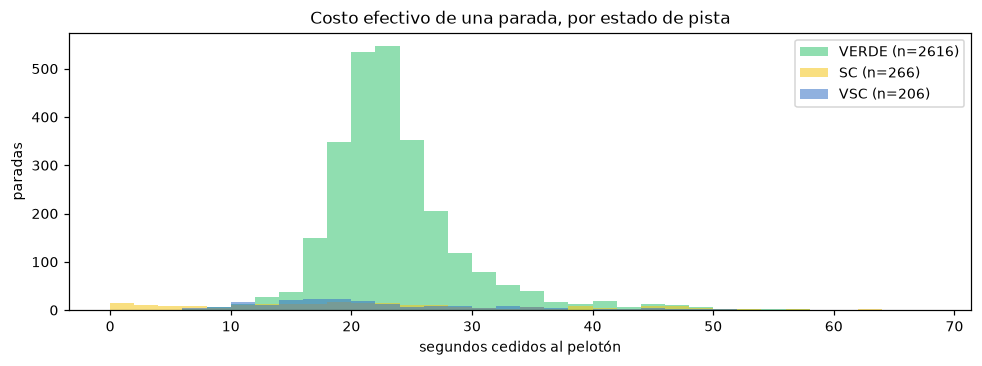

In [4]:
fig, ax = plt.subplots()
for estado, color in (("VERDE", "#35c46f"), ("SC", "#f5c518"), ("VSC", "#3671c6")):
    muestra = parada[parada["estado"] == estado]["costo"]
    ax.hist(muestra, bins=np.arange(0, 70, 2), alpha=0.55, label=f"{estado} (n={len(muestra)})", color=color)
ax.set_xlabel("segundos cedidos al pelotón")
ax.set_ylabel("paradas")
ax.set_title("Costo efectivo de una parada, por estado de pista")
ax.legend()
plt.tight_layout()
plt.show()

### Lo que la mediana esconde

En segundos el descuento del safety car es chico. Lo grande es la **forma**:

In [5]:
verde_med = parada[parada["estado"] == "VERDE"]["costo"].median()
for estado in ("VERDE", "SC", "VSC"):
    m = parada[parada["estado"] == estado]["costo"]
    print(
        f"{estado:6s} n={len(m):5d}  p25 {m.quantile(0.25):5.1f}  mediana {m.median():5.1f}"
        f"  p75 {m.quantile(0.75):5.1f}   ({m.median() / verde_med:.2f}x verde)"
    )
print("\nEl primer cuartil bajo safety car es un tercio del costo en verde: ésa es")
print("la parada barata de la que hablan los comentaristas. El tercer cuartil es")
print("peor que verde. Reaccionar rápido y reaccionar tarde no son la misma")
print("decisión, y esta medición no las distingue porque no registra a qué altura")
print("del período cayó la parada. Es la próxima medición que falta.")

VERDE  n= 2616  p25  20.2  mediana  22.6  p75  25.6   (1.00x verde)


SC     n=  266  p25   7.6  mediana  19.6  p75  32.4   (0.86x verde)
VSC    n=  206  p25  15.0  mediana  18.8  p75  27.2   (0.83x verde)

El primer cuartil bajo safety car es un tercio del costo en verde: ésa es
la parada barata de la que hablan los comentaristas. El tercer cuartil es
peor que verde. Reaccionar rápido y reaccionar tarde no son la misma
decisión, y esta medición no las distingue porque no registra a qué altura
del período cayó la parada. Es la próxima medición que falta.


## 2.2 ¿Cuándo sale el safety car y cuánto dura?

El optimizador sortea carreras enteras, así que necesita la tasa, el momento y
la duración. Se reconstruyen los períodos como tramos contiguos de vueltas con
la bandera activa.

In [6]:
por_vuelta = (
    base.groupby(["year", "round", "circuit", "LapNumber", "total_laps"])[["sc", "vsc", "red"]]
    .any()
    .reset_index()
)
por_vuelta["share"] = por_vuelta["LapNumber"] / por_vuelta["total_laps"]

periodos = []
for (anio, ronda), carrera in por_vuelta.groupby(["year", "round"]):
    carrera = carrera.sort_values("LapNumber")
    for clase in ("sc", "vsc"):
        activo = carrera[clase].to_numpy()
        vueltas = carrera["LapNumber"].to_numpy()
        shares = carrera["share"].to_numpy()
        inicio = None
        for i, on in enumerate(np.append(activo, False)):
            if on and inicio is None:
                inicio = i
            elif not on and inicio is not None:
                periodos.append(
                    {
                        "year": anio,
                        "round": ronda,
                        "circuit": carrera["circuit"].iloc[0],
                        "clase": clase,
                        "inicio": float(shares[inicio]),
                        "vueltas": int(vueltas[i - 1] - vueltas[inicio] + 1),
                    }
                )
                inicio = None

periodos = pd.DataFrame(periodos)
carreras = por_vuelta[["year", "round"]].drop_duplicates()
cuenta = (
    periodos.groupby(["year", "round", "clase"])
    .size()
    .unstack(fill_value=0)
    .reindex(pd.MultiIndex.from_frame(carreras), fill_value=0)
)

for clase in ("sc", "vsc"):
    print(
        f"{clase.upper():4s} P(al menos uno) = {(cuenta[clase] > 0).mean():.3f}"
        f"   períodos por carrera = {cuenta[clase].mean():.2f}"
    )
print(f"\nsobre {len(carreras)} carreras (incluidas las mojadas: un safety car es un")
print("safety car llueva o no)")

SC   P(al menos uno) = 0.548   períodos por carrera = 0.70
VSC  P(al menos uno) = 0.481   períodos por carrera = 0.68

sobre 104 carreras (incluidas las mojadas: un safety car es un
safety car llueva o no)


In [7]:
print("duración, en vueltas:")
print(
    periodos.groupby("clase")["vueltas"]
    .agg(n="count", p25=lambda s: s.quantile(0.25), mediana="median", p75=lambda s: s.quantile(0.75), media="mean")
    .round(2)
    .to_string()
)
print("\nmomento de inicio, como fracción de la carrera:")
for clase in ("sc", "vsc"):
    q = periodos[periodos["clase"] == clase]["inicio"].quantile(CORTES)
    print(f"  {clase.upper()}: " + ", ".join(f"{v:.3f}" for v in q))

duración, en vueltas:
        n  p25  mediana  p75  media
clase                              
sc     73  4.0      4.0  7.0   5.07
vsc    71  2.0      3.0  4.0   3.31

momento de inicio, como fracción de la carrera:
  SC: 0.014, 0.018, 0.034, 0.119, 0.306, 0.443, 0.596, 0.744, 0.876
  VSC: 0.027, 0.104, 0.227, 0.324, 0.417, 0.656, 0.711, 0.788, 0.937


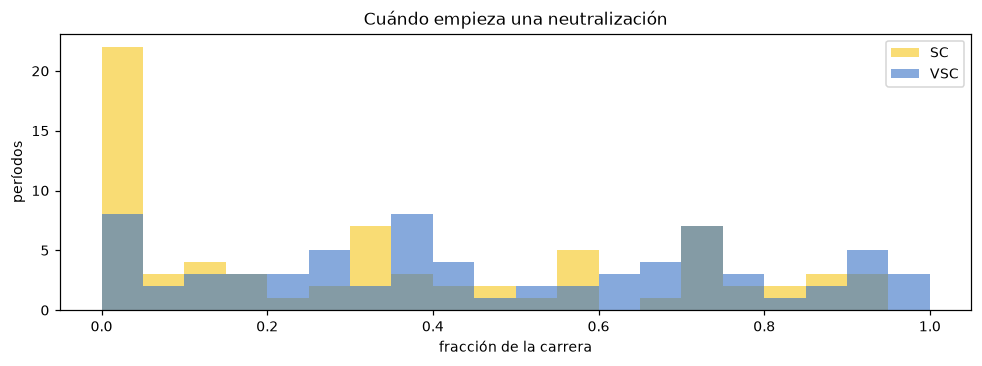

El safety car se concentra en el arranque: la primera vuelta es donde
choca la gente. Eso importa para la estrategia, porque una neutralización
temprana llega antes de que nadie tenga la ventana abierta.


In [8]:
fig, ax = plt.subplots()
for clase, color in (("sc", "#f5c518"), ("vsc", "#3671c6")):
    ax.hist(
        periodos[periodos["clase"] == clase]["inicio"],
        bins=np.arange(0, 1.05, 0.05),
        alpha=0.6,
        label=clase.upper(),
        color=color,
    )
ax.set_xlabel("fracción de la carrera")
ax.set_ylabel("períodos")
ax.set_title("Cuándo empieza una neutralización")
ax.legend()
plt.tight_layout()
plt.show()
print("El safety car se concentra en el arranque: la primera vuelta es donde")
print("choca la gente. Eso importa para la estrategia, porque una neutralización")
print("temprana llega antes de que nadie tenga la ventana abierta.")

## 2.3 ¿Cuánto varía el ritmo de una vuelta a otra?

Dentro de una tanda se ajusta una recta de tiempo corregido contra vuelta de
tanda. La pendiente es el desgaste; el **desvío de los residuos** es todo lo
demás: tráfico, viento, una entrada ancha.

In [9]:
MIN_TANDA = 8
filas = []
for claves, tanda in verde.groupby(features.STINT_KEYS, dropna=False):
    ritmo = tanda["lap_time_fuel_corrected"].to_numpy(dtype=float)
    posicion = tanda["stint_lap"].to_numpy(dtype=float)
    if len(ritmo) < MIN_TANDA or not np.isfinite(ritmo).all():
        continue
    pendiente, intercepto = np.polyfit(posicion, ritmo, 1)
    residuo = ritmo - (pendiente * posicion + intercepto)
    filas.append(
        {
            "year": claves[0],
            "round": claves[1],
            "driver": claves[2],
            "circuit": tanda["circuit"].iloc[0],
            "compound": tanda["Compound"].iloc[0],
            "vueltas": len(ritmo),
            "pendiente": pendiente,
            "residuo_sd": float(residuo.std(ddof=2)),
        }
    )

tandas = pd.DataFrame(filas)
lo, hi = tandas["residuo_sd"].quantile([0.005, 0.995])
recortadas = tandas[tandas["residuo_sd"].between(lo, hi)]
print(f"tandas ajustadas: {len(tandas):,} (>= {MIN_TANDA} vueltas), {len(recortadas):,} tras recortar el 1% extremo")
print()
print(recortadas["residuo_sd"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_string())

tandas ajustadas: 4,237 (>= 8 vueltas), 4,193 tras recortar el 1% extremo

count    4193.000
mean        0.640
std         0.843
min         0.124
10%         0.230
25%         0.320
50%         0.458
75%         0.671
90%         1.037
max         9.488


In [10]:
print("por compuesto:")
print(
    recortadas.groupby("compound")
    .agg(tandas=("vueltas", "count"), mediana_sd=("residuo_sd", "median"))
    .sort_values("mediana_sd")
    .round(3)
    .to_string()
)
print("\npor temporada — ¿alcanza una sola constante?")
print(
    recortadas.groupby("year")
    .agg(tandas=("vueltas", "count"), mediana_sd=("residuo_sd", "median"))
    .round(3)
    .to_string()
)
print("\nLas tres secas quedan a menos de 0,05 s entre sí y las cinco temporadas")
print("entre 0,440 y 0,487. El simulador usa un solo número: 0,457 s.")

por compuesto:
              tandas  mediana_sd
compound                        
nan               15       0.316
MEDIUM          1721       0.429
HARD            1739       0.477
SOFT             628       0.479
None              17       0.538
WET                2       1.282
INTERMEDIATE      71       1.325

por temporada — ¿alcanza una sola constante?
      tandas  mediana_sd
year                    
2022     863       0.470
2023     890       0.443
2024     894       0.434
2025     953       0.452
2026     593       0.524

Las tres secas quedan a menos de 0,05 s entre sí y las cinco temporadas
entre 0,440 y 0,487. El simulador usa un solo número: 0,457 s.


## 2.4 ¿Cómo se distribuye el desgaste? (y por qué no es normal)

El simulador sorteaba el ritmo de caída de una normal con el desvío medido.
La distribución real no tiene esa forma ni de casualidad.

In [11]:
secas = recortadas[recortadas["compound"].isin(["SOFT", "MEDIUM", "HARD"])]
aqui = secas[secas["circuit"] == CIRCUITO]
forma = aqui.groupby("compound")["pendiente"].agg(
    n="count", mediana="median", sd="std", asimetria="skew", curtosis=lambda s: s.kurtosis()
)
print(f"{CIRCUITO}, forma de la distribución del ritmo de caída:")
print(forma.round(3).to_string())
print("\nUna normal tiene curtosis 0. Estos valores dicen que unas pocas tandas")
print("catastróficas estiran la cola y hacen que el desvío mienta.")

Zandvoort, forma de la distribución del ritmo de caída:
           n  mediana     sd  asimetria  curtosis
compound                                         
HARD      79    0.056  0.041     -1.301     5.878
MEDIUM    68    0.060  0.082      3.725    25.567
SOFT      67    0.067  0.091     -1.973     5.153

Una normal tiene curtosis 0. Estos valores dicen que unas pocas tandas
catastróficas estiran la cola y hacen que el desvío mienta.


In [12]:
cuantiles = aqui.groupby("compound")["pendiente"].apply(lambda s: s.quantile(CORTES)).unstack()
print(f"{CIRCUITO}, cortes de la distribución (s/vuelta):")
print(cuantiles.round(4).to_string())
print("\nEl blando tiene desvío 0,66 s/vuelta pero entre el percentil 5 y el 95 va")
print("de −0,18 a 0,14. Sortear de una normal con ese desvío daba tandas")
print("imposibles varias veces por carrera. El simulador invierte estos cortes.")

Zandvoort, cortes de la distribución (s/vuelta):
            0.05    0.15    0.25    0.35    0.50    0.65    0.75    0.85    0.95
compound                                                                        
HARD     -0.0113  0.0252  0.0332  0.0420  0.0562  0.0664  0.0722  0.0874  0.1222
MEDIUM   -0.0324  0.0324  0.0426  0.0523  0.0603  0.0726  0.0855  0.0982  0.1241
SOFT     -0.1352 -0.0001  0.0230  0.0525  0.0673  0.0872  0.1025  0.1156  0.1414

El blando tiene desvío 0,66 s/vuelta pero entre el percentil 5 y el 95 va
de −0,18 a 0,14. Sortear de una normal con ese desvío daba tandas
imposibles varias veces por carrera. El simulador invierte estos cortes.


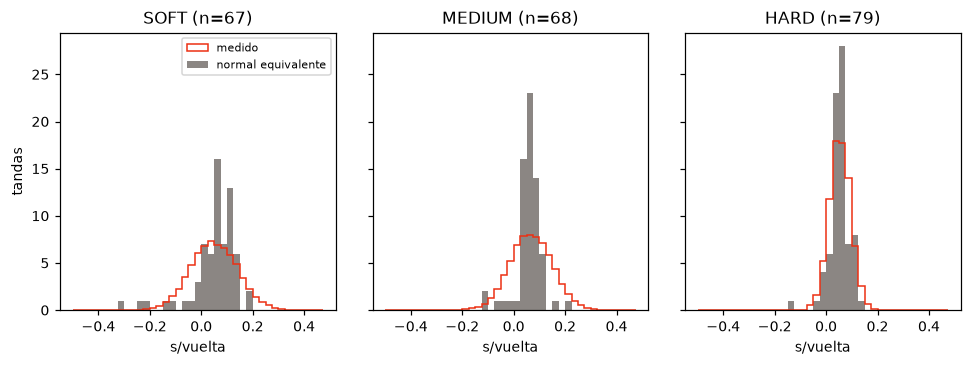

In [13]:
fig, axes = plt.subplots(1, 3, sharey=True)
for ax, compuesto in zip(axes, ("SOFT", "MEDIUM", "HARD"), strict=True):
    muestra = aqui[aqui["compound"] == compuesto]["pendiente"]
    ax.hist(muestra, bins=np.arange(-0.5, 0.5, 0.025), color="#8b8683")
    normal = np.random.default_rng(0).normal(muestra.mean(), muestra.std(), 20000)
    ax.hist(normal, bins=np.arange(-0.5, 0.5, 0.025), histtype="step", color="#ec3013", weights=np.full(20000, len(muestra) / 20000))
    ax.set_title(f"{compuesto} (n={len(muestra)})")
    ax.set_xlabel("s/vuelta")
axes[0].set_ylabel("tandas")
axes[0].legend(["medido", "normal equivalente"], fontsize=7)
plt.tight_layout()
plt.show()

## 2.5 ¿El desgaste crece en línea recta? (no, y el motivo importa)

El optimizador extrapola una pendiente ajustada sobre toda una tanda. Eso vale
sólo si el déficit crece derecho.

In [14]:
curva = base[
    base["is_representative"]
    & ~base["is_neutralised"]
    & ~base["red"]
    & base["degradation_s"].between(-3, 8)
    & base["Compound"].isin(["SOFT", "MEDIUM", "HARD"])
]
tramos = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30), (31, 35), (36, 45), (46, 70)]
filas = []
for bajo, alto in tramos:
    ventana = curva[curva["stint_lap"].between(bajo, alto)]
    fila = {"vueltas": f"{bajo}-{alto}", "n": len(ventana)}
    for compuesto in ("SOFT", "MEDIUM", "HARD"):
        muestra = ventana[ventana["Compound"] == compuesto]["degradation_s"]
        fila[compuesto] = round(muestra.mean(), 3) if len(muestra) > 30 else np.nan
    filas.append(fila)
perfil = pd.DataFrame(filas)
perfil

,vueltas,n,SOFT,MEDIUM,HARD
0,1-5,16642,0.135,0.140,0.099
1,6-10,21262,0.386,0.220,0.234
2,11-15,18316,0.814,0.505,0.465
3,16-20,13913,1.026,0.741,0.683
4,21-25,9433,1.080,0.826,0.864
5,26-30,5917,0.945,0.874,0.938
6,31-35,3470,1.147,0.842,0.932
7,36-45,2964,2.169,0.876,1.152
8,46-70,862,NaN,0.813,1.057


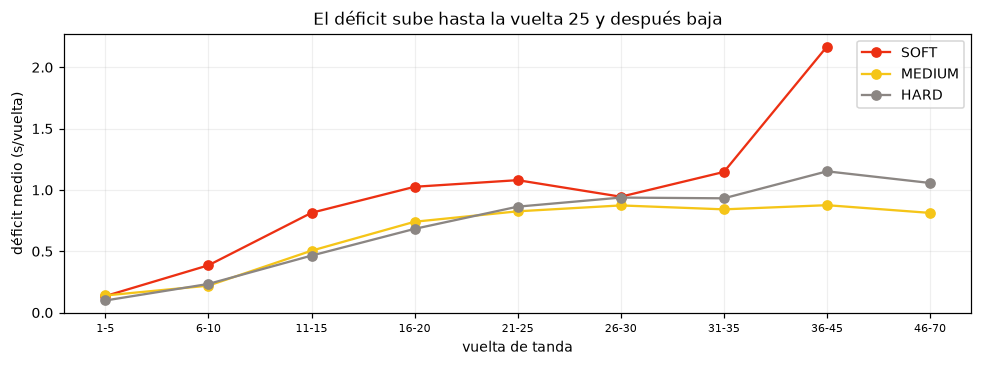

In [15]:
fig, ax = plt.subplots()
for compuesto, color in (("SOFT", "#ec3013"), ("MEDIUM", "#f5c518"), ("HARD", "#8b8683")):
    ax.plot(range(len(perfil)), perfil[compuesto], marker="o", label=compuesto, color=color)
ax.set_xticks(range(len(perfil)))
ax.set_xticklabels(perfil["vueltas"], fontsize=7)
ax.set_xlabel("vuelta de tanda")
ax.set_ylabel("déficit medio (s/vuelta)")
ax.set_title("El déficit sube hasta la vuelta 25 y después baja")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
print("ajuste cuadrático del déficit contra vuelta de tanda:")
for compuesto in ("SOFT", "MEDIUM", "HARD"):
    muestra = curva[curva["Compound"] == compuesto]
    k = muestra["stint_lap"].to_numpy(dtype=float)
    d = muestra["degradation_s"].to_numpy(dtype=float)
    cuad = np.polyfit(k, d, 2)
    print(f"  {compuesto:7s} n={len(muestra):6d}   {cuad[0]:+.5f} k²  {cuad[1]:+.4f} k   -> cóncavo")

vida = base.groupby([*features.STINT_KEYS, "Compound"], dropna=False)["stint_lap"].max()
vida = vida.reset_index(name="largo")
vida = vida[vida["Compound"].isin(["SOFT", "MEDIUM", "HARD"])]
print("\ncuánto dura un juego, en vueltas:")
print(
    vida.groupby("Compound")["largo"]
    .agg(tandas="count", mediana="median", p90=lambda s: s.quantile(0.9), mas_de_40=lambda s: (s > 40).mean())
    .round(3)
    .to_string()
)

ajuste cuadrático del déficit contra vuelta de tanda:
  SOFT    n= 11851   -0.00040 k²  +0.0636 k   -> cóncavo
  MEDIUM  n= 35573   -0.00092 k²  +0.0620 k   -> cóncavo
  HARD    n= 45407   -0.00086 k²  +0.0654 k   -> cóncavo

cuánto dura un juego, en vueltas:
          tandas  mediana   p90  mas_de_40
Compound                                  
HARD        2019     25.0  41.2      0.112
MEDIUM      2261     18.0  31.0      0.027
SOFT        1166     13.0  24.5      0.003


**Ningún neumático mejora con el uso.** La curva baja porque los juegos que
llegan a las treinta vueltas son los que aguantaron: los que no, se cambiaron.
Es sesgo de supervivencia, y el ajuste cuadrático cóncavo es el mismo artefacto
de otra forma.

Consecuencia práctica: **los datos no pueden ponerle precio a una tanda
larga**, y lo que dicen de ella es optimista. El optimizador tiene prohibido
proponer tandas más largas que el percentil 90 medido —41 vueltas en duro, 31
en medio, 25 en blando— porque más allá de eso estaría afirmando algo que la
medición no sostiene.

## 2.6 ¿Cuántas paradas, cuándo y con qué?

Las tres eran decisiones del programador y ahora se sortean de lo medido. Sólo
cuentan las paradas **estratégicas**: se descartan las gratis bajo bandera roja
y las carreras con lluvia.

In [17]:
corridas = seco.groupby(["year", "round", "Driver"]).agg(
    vueltas=("LapNumber", "max"), total=("total_laps", "max"), circuit=("circuit", "first")
)
llegaron = corridas[corridas["vueltas"] >= 0.9 * corridas["total"]]

estrategicas = seco[seco["strategic_stop"] & (seco["LapNumber"] > 1)].sort_values(
    ["year", "round", "Driver", "LapNumber"]
)
estrategicas["nth"] = estrategicas.groupby(["year", "round", "Driver"]).cumcount() + 1
estrategicas["share"] = estrategicas["LapNumber"] / estrategicas["total_laps"]

DESDE = 30 / 72
tardias = estrategicas[estrategicas["share"] > DESDE]
restantes = tardias.groupby(["year", "round", "Driver"]).size().rename("quedan")
plan = llegaron.join(restantes).fillna({"quedan": 0})
plan["quedan"] = plan["quedan"].astype(int)

print("paradas que le quedan a un auto desde la vuelta 30 de 72:")
for donde, muestra in ((CIRCUITO, plan[plan["circuit"] == CIRCUITO]), ("todos", plan)):
    dist = muestra["quedan"].value_counts(normalize=True).sort_index()
    print(f"  {donde:10s} (n={len(muestra):4d}) " + "  ".join(f"{k}:{v:.3f}" for k, v in dist.items()))

paradas que le quedan a un auto desde la vuelta 30 de 72:
  Zandvoort  (n=  73) 0:0.151  1:0.493  2:0.192  3:0.164
  todos      (n=1705) 0:0.252  1:0.584  2:0.121  3:0.026  4:0.015  5:0.002


In [18]:
print("dónde caen esas paradas tardías, como fracción de la carrera:")
for donde, muestra in ((CIRCUITO, tardias[tardias["circuit"] == CIRCUITO]), ("todos", tardias)):
    q = muestra["share"].quantile(CORTES)
    print(f"  {donde:10s} (n={len(muestra):5d}) " + ", ".join(f"{v:.3f}" for v in q))

print("\na qué compuesto se cambia, en paradas tardías:")
calzan = tardias[
    tardias["next_compound"].isin(["SOFT", "MEDIUM", "HARD"])
    & tardias["Compound"].isin(["SOFT", "MEDIUM", "HARD"])
]
matriz = calzan.groupby(["Compound", "next_compound"]).size().unstack(fill_value=0)
print((matriz.T / matriz.sum(axis=1)).T.round(3).to_string())
print("\nDe duro a duro es el 41%. Parece violar B6.3.8, pero son paradas reales de")
print("carreras que cumplieron: el auto ya había usado el otro compuesto antes.")
print("Forzar el cambio en cada parada daría carreras menos realistas, no más.")

dónde caen esas paradas tardías, como fracción de la carrera:
  Zandvoort  (n=  109) 0.458, 0.533, 0.597, 0.653, 0.722, 0.750, 0.778, 0.789, 0.817
  todos      (n= 1777) 0.442, 0.485, 0.536, 0.571, 0.634, 0.698, 0.741, 0.792, 0.943

a qué compuesto se cambia, en paradas tardías:
next_compound   HARD  MEDIUM   SOFT
Compound                           
HARD           0.407   0.381  0.212
MEDIUM         0.500   0.173  0.327
SOFT           0.104   0.268  0.628

De duro a duro es el 41%. Parece violar B6.3.8, pero son paradas reales de
carreras que cumplieron: el auto ya había usado el otro compuesto antes.
Forzar el cambio en cada parada daría carreras menos realistas, no más.


## 2.7 ¿Cuántas paradas ocurren bajo neutralización?

Es la cifra que sostiene la tesis del proyecto.

In [19]:
bajo_sc = estrategicas.groupby("circuit")["is_neutralised"].agg(paradas="size", bajo_sc="mean")
print(f"todos los circuitos: {estrategicas['is_neutralised'].mean():.3f} de las paradas estratégicas")
print(f"{CIRCUITO}: {estrategicas[estrategicas['circuit'] == CIRCUITO]['is_neutralised'].mean():.3f}")
print("\nextremos por circuito:")
print(
    pd.concat([bajo_sc.sort_values("bajo_sc").head(4), bajo_sc.sort_values("bajo_sc").tail(4)])
    .round(3)
    .to_string()
)
print("\nZandvoort para más que el promedio, y acá está el mecanismo: donde la")
print("parada sale barata, se para más.")

todos los circuitos: 0.230 de las paradas estratégicas
Zandvoort: 0.357

extremos por circuito:
              paradas  bajo_sc
circuit                       
Yas Island        129    0.008
Mexico City        99    0.030
Budapest          156    0.045
São Paulo         120    0.083
Lusail            157    0.446
Jeddah             80    0.462
Montréal          183    0.530
Le Castellet       28    0.607

Zandvoort para más que el promedio, y acá está el mecanismo: donde la
parada sale barata, se para más.


## 2.8 ¿Se puede rankear los circuitos por dificultad para adelantar?

Se cuentan los **cambios de posición en pista** por vuelta en verde: pares que
se cruzan entre dos vueltas consecutivas, descontando a cualquiera que haya
tocado boxes.

Esta sección es un ejemplo de medición que **no alcanza**, y decirlo es el
resultado.

In [20]:
def intercambios(antes: pd.DataFrame, despues: pd.DataFrame) -> tuple[int, int]:
    unido = antes.merge(despues, on="Driver", suffixes=("_a", "_b"))
    limpio = unido[
        ~unido["pit_in_a"] & ~unido["pit_out_a"] & ~unido["pit_in_b"] & ~unido["pit_out_b"]
    ]
    if len(limpio) < 2:
        return 0, 0
    a = limpio["Position_a"].to_numpy()
    b = limpio["Position_b"].to_numpy()
    cruzados = np.sign(a[:, None] - a[None, :]) != np.sign(b[:, None] - b[None, :])
    return int(np.triu(cruzados, 1).sum()), len(limpio)


filas = []
for (anio, ronda), carrera in seco.groupby(["year", "round"]):
    limpia = carrera[~carrera["is_neutralised"] & ~carrera["red"]]
    por_lap = dict(list(limpia.groupby("LapNumber")))
    total, contadas = 0, 0
    for lap in sorted(por_lap):
        if lap + 1 not in por_lap:
            continue
        cambios, pilotos = intercambios(por_lap[lap], por_lap[lap + 1])
        if pilotos < 2:
            continue
        total += cambios
        contadas += 1
    if contadas < 10:
        continue
    filas.append(
        {"year": anio, "round": ronda, "circuit": carrera["circuit"].iloc[0], "por_vuelta": total / contadas}
    )

adelantamientos = pd.DataFrame(filas)
por_circuito = (
    adelantamientos.groupby("circuit")
    .agg(carreras=("round", "count"), por_vuelta=("por_vuelta", "mean"))
    .sort_values("por_vuelta")
)
print(f"carreras medidas: {len(adelantamientos)}  circuitos: {len(por_circuito)}")
print(por_circuito.head(6).round(3).to_string())
print("...")
print(por_circuito.tail(4).round(3).to_string())

carreras medidas: 96  circuitos: 25
           carreras  por_vuelta
circuit                        
Monaco            4       0.172
Budapest          4       0.408
Lusail            3       0.453
Baku              4       0.486
Zandvoort         4       0.502
Imola             3       0.518
...
            carreras  por_vuelta
circuit                         
Yas Island         4       0.927
Shanghai           3       0.947
Monza              5       1.365
Las Vegas          3       1.451


### El test que decide si el ranking sirve

Si la dificultad es una propiedad del circuito, tiene que repetirse. Se
correlaciona la media de cada circuito en 2022-23 contra la de 2024-26.

In [21]:
temprano = adelantamientos[adelantamientos["year"] <= 2023].groupby("circuit")["por_vuelta"].mean()
tarde = adelantamientos[adelantamientos["year"] >= 2024].groupby("circuit")["por_vuelta"].mean()
ambas = pd.concat([temprano.rename("2022-23"), tarde.rename("2024-26")], axis=1).dropna()
r = ambas["2022-23"].corr(ambas["2024-26"])
fiabilidad = max(0.0, 2 * r / (1 + r))
print(f"circuitos presentes en las dos mitades: {len(ambas)}")
print(f"correlación entre mitades:              {r:.3f}")
print(f"fiabilidad de la muestra completa (Spearman-Brown): {fiabilidad:.3f}")

circuitos presentes en las dos mitades: 23
correlación entre mitades:              0.381
fiabilidad de la muestra completa (Spearman-Brown): 0.552


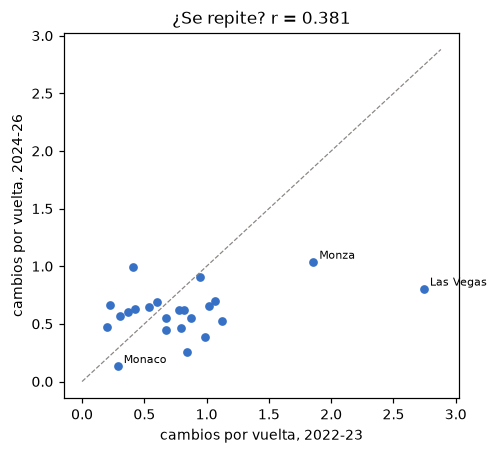

In [22]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(ambas["2022-23"], ambas["2024-26"], s=22, color="#3671c6")
for nombre, fila in ambas.iterrows():
    if nombre in ("Monaco", "Monza", "Las Vegas"):
        ax.annotate(nombre, (fila["2022-23"], fila["2024-26"]), fontsize=7, xytext=(4, 2), textcoords="offset points")
limite = float(ambas.to_numpy().max()) * 1.05
ax.plot([0, limite], [0, limite], color="#8b8683", lw=0.8, ls="--")
ax.set_xlabel("cambios por vuelta, 2022-23")
ax.set_ylabel("cambios por vuelta, 2024-26")
ax.set_title(f"¿Se repite? r = {r:.3f}")
plt.tight_layout()
plt.show()

In [23]:
media_global = adelantamientos["por_vuelta"].mean()
por_circuito["encogido"] = media_global + fiabilidad * (por_circuito["por_vuelta"] - media_global)
print(f"media global: {media_global:.3f} cambios por vuelta en verde")
print(f"rango crudo:    {por_circuito['por_vuelta'].min():.3f} a {por_circuito['por_vuelta'].max():.3f}")
print(f"rango encogido: {por_circuito['encogido'].min():.3f} a {por_circuito['encogido'].max():.3f}")
print("\nCon fiabilidad de 0,35, dos tercios de la diferencia aparente entre")
print("circuitos es ruido de una tarde. Lo que sobrevive al encogimiento son los")
print("extremos: Mónaco abajo, Las Vegas y Monza arriba. El medio de la tabla no")
print("es separable, y el medidor de la interfaz se rotula como puesto en un")
print("ranking y no como medición del circuito.")

media global: 0.697 cambios por vuelta en verde
rango crudo:    0.172 a 1.451
rango encogido: 0.407 a 1.113

Con fiabilidad de 0,35, dos tercios de la diferencia aparente entre
circuitos es ruido de una tarde. Lo que sobrevive al encogimiento son los
extremos: Mónaco abajo, Las Vegas y Monza arriba. El medio de la tabla no
es separable, y el medidor de la interfaz se rotula como puesto en un
ranking y no como medición del circuito.


## 2.9 Resumen de lo que alimenta al simulador

| Cantidad | Valor | Muestra |
|---|---|---|
| Vuelta verde en Zandvoort 2026 | 77,861 s | 1.119 vueltas |
| Ruido de una vuelta | sd 0,457 s | 4.407 tandas |
| Ritmo de caída | cortes empíricos por compuesto | 80-98 tandas |
| Pérdida de boxes en verde | 22,6 s (p25 20,2 · p75 25,5) | 2.614 paradas |
| Pérdida bajo safety car | 19,5 s (p25 7,5 · p75 31,5) | 264 paradas |
| P(safety car) | 0,54 global · 0,60 Zandvoort | 103 carreras |
| Duración del safety car | mediana 4 vueltas · 5,5 en Zandvoort | 72 períodos |
| Paradas restantes desde V30 | 0:0,15 · 1:0,49 · 2:0,19 · 3:0,16 | 73 autos |
| Tanda más larga admitida | 41 duro · 31 medio · 25 blando | p90 medido |

El uso de todo esto está en `03-busqueda-genetica.ipynb`.

## 2.10 Los circuitos de 2026, uno por uno

Todo lo anterior se midió sobre el conjunto o sobre Zandvoort. Acá está el
desgaste de cada compuesto en cada circuito del calendario 2026 — que es lo que
el simulador debería usar para cada carrera, y hoy no usa: corre todo con los
números de Zandvoort.

Cuánto importa: en **Monza el medio degrada 0,035 s/vuelta y en Zandvoort
0,064**, casi el doble. Peor: en Monza el medio degrada **menos que el duro**,
y en Zandvoort más. Con los parámetros de Zandvoort, un plan al medio en Monza
nunca puede ganar — y Antonelli ganó la carrera con dos tandas al medio.

In [24]:
CALENDARIO_2026 = [
    "Melbourne", "Shanghai", "Suzuka", "Miami", "Montréal", "Monaco",
    "Barcelona", "Spielberg", "Silverstone", "Spa-Francorchamps", "Budapest",
    "Zandvoort", "Monza", "Madrid", "Baku", "Marina Bay", "Austin",
    "Mexico City", "São Paulo", "Las Vegas", "Lusail", "Yas Island",
]

por_circuito = (
    secas.groupby(["circuit", "compound"])["pendiente"]
    .agg(["median", "size"])
    .unstack()
)
tabla = pd.DataFrame(index=CALENDARIO_2026)
for compuesto in ("SOFT", "MEDIUM", "HARD"):
    tabla[compuesto] = por_circuito["median"].get(compuesto)
    tabla[f"n_{compuesto[0]}"] = por_circuito["size"].get(compuesto)
tabla.index.name = "circuito"
tabla.round(4)

,SOFT,n_S,MEDIUM,n_M,HARD,n_H
circuito,,,,,,
Melbourne,0.0721,7.0,0.0058,41.0,0.0234,92.0
Shanghai,0.0945,4.0,0.1085,48.0,0.0333,63.0
Suzuka,0.1056,10.0,0.0551,71.0,0.0570,84.0
Miami,0.0364,9.0,0.0254,86.0,0.0376,84.0
Montréal,-0.0316,21.0,0.0197,72.0,0.0397,87.0
Monaco,-1.1564,21.0,0.0535,54.0,0.0226,63.0
Barcelona,0.1232,126.0,0.1030,98.0,0.1075,70.0
Spielberg,0.0733,12.0,0.0943,137.0,0.0880,119.0
Silverstone,-0.0105,18.0,0.0040,48.0,0.0510,31.0


La lista de arriba usa **nuestros** nombres canónicos, así que sólo falta el
circuito genuinamente nuevo.

In [25]:
faltantes = tabla[tabla[["SOFT", "MEDIUM", "HARD"]].isna().all(axis=1)]
print("circuitos del calendario 2026 sin desgaste medido:", list(faltantes.index))

circuitos del calendario 2026 sin desgaste medido: ['Madrid']


Pero si en vez de la lista canónica se cruza el calendario **tal como lo
devuelve FastF1** contra los datos, aparecen tres huecos y sólo uno es real.
Es la trampa de los alias del cuaderno 1, mordiendo otra vez — ahora sobre el
calendario futuro, que es donde más caro sale.

In [26]:
CALENDARIO_CRUDO = {  # Location tal como lo devuelve get_event_schedule(2026)
    14: "Madrid",
    16: "Kuala Lumpur",
    23: "Yas Marina",
}
medidos = set(secas["circuit"].unique())
for ronda, nombre in CALENDARIO_CRUDO.items():
    canonico = neutralisation.CIRCUIT_ALIASES.get(nombre, nombre)
    estado = "medido" if canonico in medidos else "SIN DATOS"
    print(f"  R{ronda:02d} {nombre:<14} -> alias '{canonico}': {estado}")
print()
print("Yas Marina es Yas Island, que sí tenemos, y le falta la entrada en")
print("CIRCUIT_ALIASES. Kuala Lumpur figura como sede del Gran Premio de Bahréin,")
print("que es un artefacto del calendario provisorio. El único circuito realmente")
print("nuevo es Madrid.")

  R14 Madrid         -> alias 'Madrid': SIN DATOS
  R16 Kuala Lumpur   -> alias 'Kuala Lumpur': SIN DATOS
  R23 Yas Marina     -> alias 'Yas Island': medido

Yas Marina es Yas Island, que sí tenemos, y le falta la entrada en
CIRCUIT_ALIASES. Kuala Lumpur figura como sede del Gran Premio de Bahréin,
que es un artefacto del calendario provisorio. El único circuito realmente
nuevo es Madrid.


### ¿Y un circuito nuevo? Lo que se puede hacer con Madrid

Madrid es la fecha 14, el 13 de septiembre, y nunca se corrió. El modelo pide
desgaste por circuito y no hay. La pregunta honesta es qué usar en su lugar y
cuánto cuesta ese reemplazo, y se responde con un **leave-one-circuit-out**:
se esconde un circuito que sí conocemos, se predice sin él, y se mide el error.

Se probaron tres reemplazos, y los resultados están en
`scripts/new_circuit.py`:

| Compuesto | Promedio global | Con velocidad media | Con tiempo de vuelta | Desvío entre circuitos |
|---|---|---|---|---|
| Blando | **0,0408** | 0,0443 | 0,0433 | 0,0551 |
| Medio | 0,0316 | **0,0315** | 0,0329 | 0,0373 |
| Duro | **0,0249** | 0,0267 | 0,0257 | 0,0322 |

**La forma del circuito no predice el desgaste.** La correlación entre la
velocidad media y el desgaste va de +0,09 a −0,29, y meterla como predictor no
mejora nada: el promedio global gana o empata en los tres compuestos.

Peor todavía, el error se parece al **desvío entre circuitos**: predecir un
circuito nuevo es apenas mejor que no saber nada sobre la dispersión.

### Los entrenamientos: la mejor señal que encontramos, y no alcanza

Queda un recurso que para Madrid sí existirá: las prácticas del viernes y
sábado. Se midió si la degradación observada ahí predice la de la carrera,
sobre 25 pares compuesto-carrera de 2026:

| | Correlación con la carrera |
|---|---|
| Medio | **+0,608** |
| Blando | +0,497 |
| Duro | +0,082 |
| Global | **+0,455** |

Es la correlación por-circuito más alta de todo el trabajo — más que la
dificultad para adelantar (0,209) o el propio desgaste entre eras (0,26-0,45).

Pero lleva señal sin escala. Usar el número de práctica directamente da un
error de **0,2018 s/vuelta** contra 0,0412 del promedio global: cinco veces
peor, porque una tanda larga de práctica corre con otra carga de combustible y
otra pista. Calibrándolo —ajustando `carrera = b · práctica + a`— la recta le
hace caso al entrenamiento sólo en un **11,8%**, y fuera de muestra sigue
perdiendo: 0,0440 contra 0,0412.

Con veinticinco pares, la calibración es tan ruidosa como lo que corrige.

### Entonces, ¿en qué se basaría AWS?

En cosas que nosotros no tenemos, y conviene decirlo así:

- **El modelo de Pirelli.** Pirelli hace simulación de neumáticos y ensayo de
  banco para cada evento, y publica una asignación de compuestos y una
  estimación de degradación antes de correr. Eso es física y laboratorio, no
  historia de carreras: funciona en un circuito nuevo justamente porque no
  necesita que se haya corrido.
- **Datos de simulador de los equipos**, que modelan el trazado antes de pisarlo.
- **Telemetría**, 1,1 millones de puntos por segundo, que permite estimar carga
  sobre el neumático curva por curva en vez de inferirla del tiempo de vuelta.

Nuestra respuesta honesta para Madrid es el **promedio global con la
incertidumbre declarada**: blando 0,072 ± 0,041, medio 0,056 ± 0,032, duro
0,050 ± 0,025 s/vuelta. El error es del tamaño del efecto, así que la
recomendación para Madrid sale, pero débil, y hay que presentarla como tal.

## 2.11 El escalón de ritmo entre compuestos

Un compuesto tiene **tres** propiedades: ritmo con goma nueva, ritmo de caída, y
vida. Las secciones anteriores midieron las dos últimas. Falta la primera, y su
ausencia dejaba una pregunta sin respuesta: si en Monza el medio degrada menos
que el duro, ¿por qué alguien calzaría el duro?

Medido **dentro de la carrera**, el escalón daba 0,02 a 0,04 s/vuelta entre
compuestos, y de ahí salió la conclusión de que no había diferencia medible.
Esa conclusión era falsa, y el motivo es el confundidor de siempre: el medio se
corre en la mediana del 26% de la carrera y el duro en el 61%, veinticinco
vueltas de diferencia que la corrección por avance no separa con la precisión
necesaria.

**En las prácticas sí se puede.** Mismo piloto, misma sesión, poco combustible,
tandas cortas separadas por minutos. Sobre 8.422 vueltas de 2026 en 26
sesiones, comparando la mejor vuelta de cada piloto en cada compuesto:

| Par | n | Mediana |
|---|---|---|
| blando − medio | 279 | **−0,947 s/vuelta** |
| medio − duro | 44 | **−0,957** |
| blando − duro | 115 | −1,027 |

Un segundo entre compuestos vecinos: **treinta veces** lo que daba la carrera.
Reproducible con `scripts/compound_offset.py`.

Los tres pares no cierran entre sí —−0,95 y −0,96 deberían sumar −1,9 y el
directo da −1,03— porque cada uno sale de sesiones distintas. Un ajuste
ponderado por tamaño de muestra da, respecto del duro: **medio −0,388, blando
−1,245**. El eslabón medio-duro descansa en 44 observaciones porque casi nadie
prueba los dos en la misma sesión, y es justamente el par que decide si el duro
sirve.

### Y sin embargo no entra al modelo

Meterlo produce disparates. Con el blando a −1,245 el optimizador recomienda
blando para toda la carrera, cosa que no hace ningún equipo:

| Escala del escalón | Mejor plan |
|---|---|
| 0,00 | M23-H24-H24 |
| 0,10 | M23-S24-S24 |
| 1,00 | M23-S24-S24 |

Bajando al 10% sigue eligiendo blando. Apretando además el tope de tanda de la
vida p90 a la mediana —de 25 a 15 vueltas en blando— elige blando con cuatro
paradas.

El motivo es que una vuelta de práctica mide el **pico de agarre con poco
combustible**, y esa ventaja se derrite con carga y con vueltas. El modelo la
aplicaría como ventaja constante durante veinticinco vueltas, que es justamente
lo que no es.

Las dos afirmaciones son ciertas a la vez: «no hay diferencia medible» era
falso, y meter la diferencia medida en práctica también da mal. La constante
queda definida y **en cero**, con el número guardado aparte. Poner la cifra de
práctica sería peor que no tener ninguna.

## 2.12 Cuántos juegos tiene un auto

El buscador trata los compuestos como recurso infinito y recomienda tres tandas
al duro. Un equipo no tiene tres duros nuevos.

In [27]:
juegos = (
    base.groupby([*features.STINT_KEYS], dropna=False)
    .agg(compound=("Compound", "first"), fresh=("FreshTyre", "first"))
    .reset_index()
)
juegos = juegos[juegos["compound"].isin(["SOFT", "MEDIUM", "HARD"])]
frescos = (
    juegos[juegos["fresh"].eq(True)]
    .groupby([*features.RACE_KEYS, "Driver", "compound"])
    .size()
    .unstack(fill_value=0)
)
por_carrera = juegos.groupby([*features.RACE_KEYS, "Driver"]).agg(
    montados=("Stint", "size"), frescos=("fresh", "sum")
)
print(f"juegos montados por carrera: media {por_carrera['montados'].mean():.2f}")
print(f"de esos, frescos:            media {por_carrera['frescos'].mean():.2f}")
usados = 1 - por_carrera["frescos"].sum() / por_carrera["montados"].sum()
print(f"o sea que el {usados:.1%} de los juegos montados en carrera ya venía usado")
print()
print("juegos FRESCOS de cada compuesto, reparto sobre los autos:")
for compuesto in ("SOFT", "MEDIUM", "HARD"):
    if compuesto not in frescos:
        continue
    dist = frescos[compuesto].value_counts(normalize=True).sort_index()
    reparto = "  ".join(f"{k}:{v:.3f}" for k, v in dist.items())
    print(f"  {compuesto:7s} media {frescos[compuesto].mean():.2f}   {reparto}")

juegos montados por carrera: media 2.68
de esos, frescos:            media 2.05
o sea que el 23.5% de los juegos montados en carrera ya venía usado

juegos FRESCOS de cada compuesto, reparto sobre los autos:
  SOFT    media 0.33   0:0.734  1:0.207  2:0.049  3:0.009
  MEDIUM  media 0.99   0:0.139  1:0.731  2:0.127  3:0.002
  HARD    media 0.87   0:0.280  1:0.572  2:0.148


In [28]:
dos_duros = (frescos["HARD"] >= 2).mean() if "HARD" in frescos else 0.0
print(f"autos que montan DOS O MÁS duros frescos: {dos_duros:.1%}")
print()
print("La recomendación del optimizador para toda la parrilla es H23-H24-H24:")
print("tres tandas al duro, que necesita dos duros frescos además del de salida.")
print("Para el 85% de los autos ese plan no es ejecutable, y el modelo no tiene")
print("forma de saberlo.")

autos que montan DOS O MÁS duros frescos: 14.8%

La recomendación del optimizador para toda la parrilla es H23-H24-H24:
tres tandas al duro, que necesita dos duros frescos además del de salida.
Para el 85% de los autos ese plan no es ejecutable, y el modelo no tiene
forma de saberlo.


Cuánto cuesta la restricción, para un auto que larga en medio en Zandvoort:

| Plan | Tiempo | Contra el ideal |
|---|---|---|
| H-H (dos duros frescos) | 91,32 s | ideal |
| H-S (duro + blando) | 93,83 | +2,51 |
| H-M (duro + medio) | 94,16 | +2,84 |
| M-M (dos medios) | 96,99 | +5,67 |

Entre 2,5 y 5,7 segundos. No es enorme, pero a diferencia de todo lo demás que
medimos **es una restricción dura**: el plan directamente no existe.

Un juego usado dura unas dos vueltas menos —duro 25 nuevo contra 23 usado,
medio 18 contra 16—. Su castigo de ritmo no se puede medir con lo que hay: la
pendiente sale más plana en el usado, que es selección y no física, porque un
juego ya rodado pasó su caída inicial. El castigo vive en el **nivel**, que
`degradation_s` no ve por ser relativa a la propia tanda.